# ACCESS-OM3 depth-latitude temperature and temperature difference from WOA23

Related issue: https://github.com/ACCESS-Community-Hub/access-om3-25km-paper-1/issues/11

OM2 paper figure 12 https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/temperature_biases/zonal_temp_salt_bias.ipynb

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [ ]:
if not papermill: 
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [3]:
IAF = esm_file.find('iaf') > 0
IAF

True

In [4]:
import os
import numpy as np
import xarray as xr
import cftime
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import gsw
import intake
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib as mpl
from distributed import Client
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cft
from shapely import geometry
from textwrap import wrap
from tqdm.notebook import tqdm
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36045,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39429,Total threads: 1
Dashboard: /proxy/40645/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:38689,


## Define regions

Global maxy changed from 90 to 65 to omit tripolar region


Text(0.5, 1.0, 'Regions (BUG: incorrect shapes north of 65°N)')

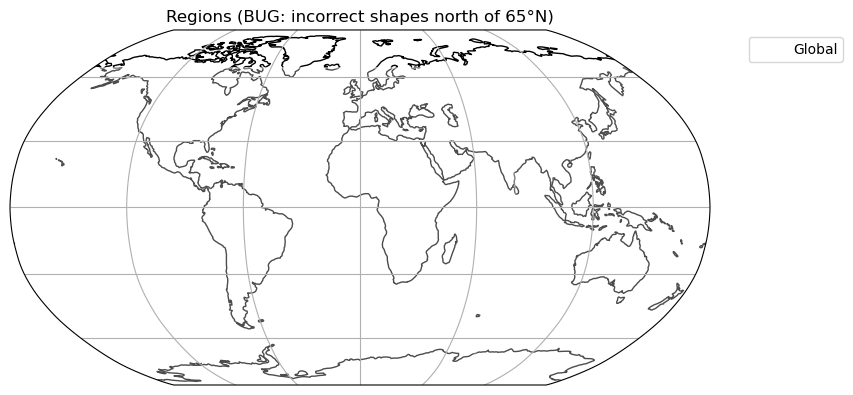

In [7]:
regions = { # [minx, maxx, miny, maxy], using model longitude range (-280 to 80)
    "Global": [-280, 80, -90, 90],
    # "Arctic": [-280, 80, 65, 90],
    # "Southern Ocean": [-280, 80, -82, -63],
    # "ACC": [-280, 80, -63, -45],
    # "Southern Pacific": [-210, -70, -45, -20],
    # "Tropical Pacific": [-240, -100, -20, 20],
    # "North Pacific": [-240, -100, 20, 65],
    # "South Atlantic": [-60, 20, -45, -20],
    # "Tropical Atlantic": [-70, 20, -20, 20],
    # "North Atlantic": [-100, 0, 20, 65],
    # "Indian": [30, 120, -45, 20],
    # "Aegean Sea": [18, 27.5, 34, 44],
    # "Black Sea": [27.5, 43, 40.5, 48],
    # "Baltic Sea": [13, 30, 53, 58],
    # "Mediterranean Sea": [0, 35, 31, 41],
    # "Red Sea": [33, 44, 12, 29],
    # "Persian Gulf": [47, 56, 24, 31],
    # "White Sea": [31, 41, 63, 68],
}
regions = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in regions.items()}  # convert to dicts

for r, d in regions.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")
        if k in ["miny", "maxy"] and x > 65:
            print(f"{r} {k} changed from {x} to 65 to omit tripolar region")
            d[k] = 65
            

fig = plt.figure(figsize=(10, 4))

colors = mpl.color_sequences['tab20']
try:  # set Global color to white 
    colors[list(regions.keys()).index("Global")] = (1, 1, 1)
except ValueError:
    pass

ax = plt.axes(position=[0.05,0.05,0.7,0.9], projection=ccrs.Robinson())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=False)

legend_elements = []
for i, (region, limits) in enumerate(regions.items()):
    ax.add_geometries([geometry.box(**limits)], crs=ccrs.PlateCarree(), color=colors[i], alpha=0.3)
    legend_elements.append(Patch(color=colors[i], alpha=0.3, label=region))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.2, 1.00))
plt.title("Regions (BUG: incorrect shapes north of 65°N)")

## Load data from ACCESS-OM3

In [8]:
om3exptname = os.path.basename(os.path.dirname(esm_file))
catalogs = [
                esm_file,
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm1-d968c801/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm2-5dc49da6/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm3-da330542/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm4-9fd08880/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-gm5-9b5dbfa9/datastore.json',
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json']

In [9]:
om3datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
om3datastores

{'MC_25km_jra_iaf+wombatlite-test4-d28e0359': <datastore catalog with 24 dataset(s) from 32795 asset(s)>}

In [10]:
om3varnames = [ 'thetao', 'so' ]  # potential temperature and practical salinity

om3vars = {
    vname: {expt: ds.search(variable=vname).to_dask(
                xarray_open_kwargs = dict(
                    chunks={"xh": -1, "yh": "auto", "z_l": "auto"},
                    decode_timedelta=True
                )
            )[vname]
            for expt, ds in om3datastores.items()
          }
    for vname in om3varnames
    }

# omit latitudes with grid bug in this run https://github.com/ACCESS-NRI/ocean_model_grid_generator/issues/7
for vname, d in om3vars.items():
    try:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yh=slice(10, None))
    except ValueError:
        d['25km-iaf-test-for-AK-expt-7df5ef4c'] = d['25km-iaf-test-for-AK-expt-7df5ef4c'].isel(yq=slice(10, None))
    except KeyError:
        pass

if IAF:
    for vname, d in om3vars.items():
        for expt in d:
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

## Load data from ACCESS-OM2
use control - see https://forum.access-hive.org.au/t/access-om2-control-experiments/258#p-747-ryf-7

In [11]:
if IAF:
    om2exptname = '025deg_jra55_iaf_omip2_cycle1'
else:
    om2exptname = '025deg_jra55_ryf9091_gadi'  # monthly temp only for 1900-1903, and 2300-, with annual data in the gap
om2datastores = {om2exptname: intake.cat.access_nri[om2exptname]}

In [12]:
om2varnames = [ 'pot_temp', 'salt' ]  # potential temperature and practical salinity

om2vars = {
    vname: {expt: ds.search(variable=vname, frequency="1mon").to_dask(
                xarray_open_kwargs = dict(
                    chunks={"xt_ocean": -1, "yt_ocean": "auto", "st_ocean" : "auto"},
                    decode_timedelta=True
                )
            )[vname]
            for expt, ds in om2datastores.items()
          }
    for vname in om2varnames
    }

if IAF:
    for vname, d in om2vars.items():
        for expt in d:
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

for expt, da in om2vars['pot_temp'].items():
    try:
        om2vars['pot_temp'][expt] = om2vars['pot_temp'][expt] - 273.15  # convert to degC
        om2vars['pot_temp'][expt].attrs['units'] = 'degC'
    except KeyError:
        pass

## Set time range

In [13]:
lasttime = []
for vname, d in om3vars.items():
    for expt, da in d.items():
        lasttime.append(da.time.values[-1])
for vname, d in om2vars.items():
    for expt, da in d.items():
        lasttime.append(da.time.values[-1])

if IAF:
    # datestop = cftime.DatetimeProlepticGregorian(2018, 12, 31, 12, 0, 0, 0, has_year_zero=True)  # to match OM2 IAF run
    datestop = min(lasttime) # earliest final date in data
    datelist = list(cftime.to_tuple(datestop))
    datelist[0] -= 25  # last 25 years
    datestart = cftime.datetime(*datelist, calendar=datestop.calendar)
    # bracket to start/end of year
    datestart = cftime.datetime(cftime.to_tuple(datestart)[0],  1, 1, calendar=datestop.calendar)
    datestop  = cftime.datetime(cftime.to_tuple(datestop)[0], 12, 31, 23, 59, 59, calendar=datestop.calendar)
    timerange = slice(datestart, datestop)
else:
    timerange = slice(cftime.DatetimeNoLeap(1932, 1, 1, 0, 0, 0, 0),
                      cftime.DatetimeNoLeap(1952, 1, 1, 0, 0, 0, 0))

# timerange = slice(None, None)

timerange

slice(cftime.datetime(1993, 1, 1, 0, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.datetime(2018, 12, 31, 23, 59, 59, 0, calendar='proleptic_gregorian', has_year_zero=True), None)

## Calculate zonal mean for each region

In [14]:
%%time
om3vars_mean = {
    region:
    {
        vname: {
                expt: da.sel(yh=slice(b['miny'], b['maxy']))\
                        .sel(xh=slice(b['minx'], b['maxx']))\
                        .sel(time=timerange)\
                        .mean('xh').mean('time').load()
                for expt, da in tqdm(vdatadict.items(), desc=f'      {vname} experiments', )
              }
        for vname, vdatadict in tqdm(om3vars.items(), desc=f'   {region} variables')
    }
    for region, b in tqdm(regions.items(), desc='regions')
}

regions:   0%|          | 0/1 [00:00<?, ?it/s]

   Global variables:   0%|          | 0/2 [00:00<?, ?it/s]

      thetao experiments:   0%|          | 0/1 [00:00<?, ?it/s]

      so experiments:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 1min 6s, sys: 29.2 s, total: 1min 35s
Wall time: 2min 7s


In [15]:
%%time
om2vars_mean = {
    region:
    {
        vname: {
                expt: da.sel(yt_ocean=slice(b['miny'], b['maxy']))\
                        .sel(xt_ocean=slice(b['minx'], b['maxx']))\
                        .sel(time=timerange)\
                        .mean('xt_ocean').mean('time').load()
                for expt, da in tqdm(vdatadict.items(), desc=f'      {vname} experiments', )
              }
        for vname, vdatadict in tqdm(om2vars.items(), desc=f'   {region} variables')
    }
    for region, b in tqdm(regions.items(), desc='regions')
}

regions:   0%|          | 0/1 [00:00<?, ?it/s]

   Global variables:   0%|          | 0/2 [00:00<?, ?it/s]

      pot_temp experiments:   0%|          | 0/1 [00:00<?, ?it/s]

      salt experiments:   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 1min 6s, sys: 29 s, total: 1min 35s
Wall time: 2min 51s


## Load data from WOA

NB: we're taking a mean of the monthly means. This reduces seasonal bias relative to the annual mean WOA (I think!), but will also involve more interpolated values.

The alternative would be to use the WOA annual mean `/g/data/ik11/observations/woa23/woa23_decav_[ts]00_04.nc` but this needs to be converted to the appropriate temperature and salinity, and regridded to model grid.


In [16]:
# fragile! obs_file_pattern depends on model run!
# obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2025.10.24/woa23_ts_*"
obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2026.06.11/woa23_ts_*"  # for MC_25km_jra_iaf+wombatlite-test4-d28e0359

om3mask = np.isfinite(om3vars['thetao'][om3exptname].isel(time=0)).load()

ds_obs = xr.open_mfdataset(
        obs_file_pattern,
        chunks={"time": -1})\
    .cf.mean("time")\
    .rename({'lon': 'xh', 'lat': 'yh', 'depth': 'z_l'})\
    .where(om3mask)  # mask out interpolated values at dry points in model

woa23vars = { k: ds_obs[k] for k in ["ptemp", "salt"] } # for OM3: potential temperature and practical salinity

# calculate zonal mean for each region
woa23vars_mean = {
    region:
    {
        vname: da.cf.sel( latitude=slice(b['miny'], b['maxy']))\
                 .cf.sel(longitude=slice(b['minx'], b['maxx']))\
                 .cf.mean('longitude')\
                 .load()
        for vname, da in tqdm(woa23vars.items(), desc=f'   {region} variables')
    }
    for region, b in tqdm(regions.items(), desc='regions')
}

regions:   0%|          | 0/1 [00:00<?, ?it/s]

   Global variables:   0%|          | 0/2 [00:00<?, ?it/s]

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 118.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 118.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [17]:
# fragile! obs_file_pattern depends on model run!
obs_file_pattern = "/g/data/ik11/observations/woa13/025_KDS50/woa13_ts_??_mom025.nc"  # for 025deg_jra55_iaf_omip2_cycle1

om2mask = np.isfinite(om2vars['pot_temp'][om2exptname].isel(time=0)).load()

ds_obs = xr.open_mfdataset(
        obs_file_pattern,
        chunks={"time": -1},
        decode_times=xr.coders.CFDatetimeCoder(use_cftime=True))\
    .cf.mean("time")\
    .rename({'GRID_X_T': 'xt_ocean', 'GRID_Y_T': 'yt_ocean', 'ZT': 'st_ocean'})

# fix to handle slightly different st_ocean precision
ds_obs.coords['st_ocean'] = om2mask.coords['st_ocean'].values
       
ds_obs = ds_obs.where(om2mask)  # mask out interpolated values at dry points in model

woa13vars = { k: ds_obs[k] for k in ["temp", "salt"] } # for OM2: potential temperature and practical salinity

# calculate zonal mean for each region
woa13vars_mean = {
    region:
    {
        vname: da.cf.sel( latitude=slice(b['miny'], b['maxy']))\
                 .cf.sel(longitude=slice(b['minx'], b['maxx']))\
                 .cf.mean('longitude')\
                 .load()
        for vname, da in tqdm(woa13vars.items(), desc=f'   {region} variables')
    }
    for region, b in tqdm(regions.items(), desc='regions')
}

regions:   0%|          | 0/1 [00:00<?, ?it/s]

   Global variables:   0%|          | 0/2 [00:00<?, ?it/s]

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 58.09 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 58.09 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


### alternative approach for WOA data - not used

Would need to interpolate WOA data onto model grid

## Regridders
See https://github.com/aekiss/ice_analysis/blob/main/ice_maps.ipynb

## Plot zonal means for each region

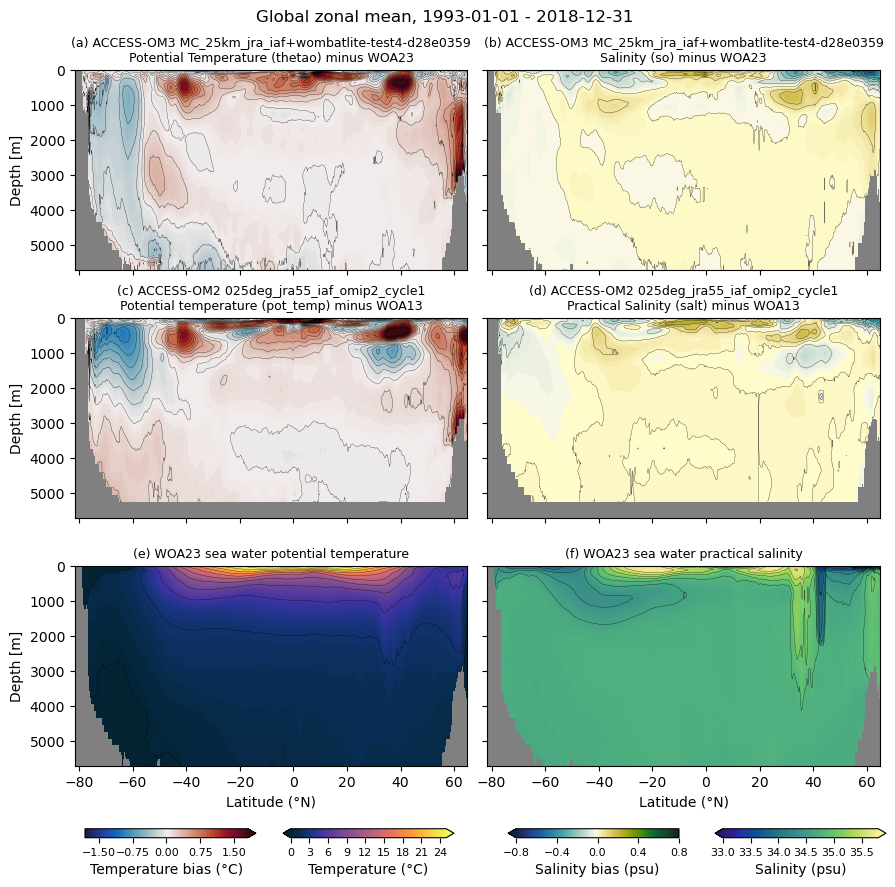

In [18]:
for region, d in om3vars_mean.items():
    om3variable = "thetao"  # potential temperature
    om2variable = "pot_temp"  # potential temperature
    woa23variable = "ptemp"  # potential temperature
    woa13variable = "temp"  # potential temperature

    npanels = 2 * (len(d[om3variable]) + len(om2vars_mean[region][om2variable]) + 1)
    nrows = (npanels+1)//2
    fig, axs = plt.subplots(nrows, 2,
                            figsize=(9, 3*nrows),
                            sharex=True, sharey=True)
    fig.suptitle(f'{region} zonal mean, {timerange.start.strftime("%Y-%m-%d")} - {timerange.stop.strftime("%Y-%m-%d")}', y=0.98)

    # Column 1: Temperature
    cmap = cmocean.cm.balance

    vlim = -1
    for da in d[om3variable].values():
        vlim = max(vlim, np.abs(da - woa23vars_mean[region][woa23variable]).max().data)
    for da in om2vars_mean[region][om2variable].values():
        vlim = max(vlim, np.abs(da - woa13vars_mean[region][woa13variable]).max().data)

    vlim = 1.8 # to match Kiss et al 2020 fig 12

    # ACCESS-OM3
    for i, (expt, da) in enumerate(d[om3variable].items()):
        # print(da)
        plt.subplot(nrows, 2, 2*i+1).set_facecolor('gray')  # gray land points
        p = (da - woa23vars_mean[region][woa23variable]).plot.contourf(
            levels=101, vmin=-vlim, vmax=vlim, cmap=cmap, add_colorbar=False,
        )
        (da - woa23vars_mean[region][woa23variable]).plot.contour(
            levels=25, vmin=-vlim, vmax=vlim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i)}) ACCESS-OM3 {expt}\n{da.attrs['long_name']} ({om3variable}) minus WOA23", fontsize=9)
        plt.xlabel('')
        plt.ylabel('Depth [m]')

    # ACCESS-OM2
    for i, (expt, da) in enumerate(om2vars_mean[region][om2variable].items(), start=i+1):
        plt.subplot(nrows, 2, 2*i+1).set_facecolor('gray')  # gray land points
        p1 = (da - woa13vars_mean[region][woa13variable]).plot.contourf(
            levels=101, vmin=-vlim, vmax=vlim, cmap=cmap, add_colorbar=False,
        )
        (da - woa13vars_mean[region][woa13variable]).plot.contour(
            levels=25, vmin=-vlim, vmax=vlim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i)}) ACCESS-OM2 {expt}\n{da.attrs['long_name']} ({om2variable}) minus WOA13", fontsize=9)
        plt.xlabel('')
        plt.ylabel('Depth [m]')

    # WOA23
    i += 1
    cmap = cmocean.cm.thermal
    da = woa23vars_mean[region][woa23variable]
    plt.subplot(nrows, 2, 2*i+1).set_facecolor('gray')  # gray land points
    p4 = da.plot.contourf(
        levels=101, cmap=cmap, add_colorbar=False,
        vmin=0, vmax=25  # to match Kiss et al 2020 fig 12
    )
    da.plot.contour(
        levels=25, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
    )
    plt.gca().set_ylim([0, None])
    plt.gca().invert_yaxis()
    plt.title(f"({chr(ord('a')+2*i)}) WOA23 {da.attrs['standard_name'].replace('_', ' ')}", fontsize=9)
    plt.xlabel('Latitude (°N)')
    plt.ylabel('Depth [m]')

    # Column 2: Salt
    om3variable = "so"
    om2variable = "salt"
    woa23variable = "salt"
    woa13variable = "salt"
    cmap = cmocean.cm.delta

    vlim = -1
    for da in d[om3variable].values():
        vlim = max(vlim, np.abs(da - woa23vars_mean[region][woa23variable]).max().data)
    for da in om2vars_mean[region][om2variable].values():
        vlim = max(vlim, np.abs(da - woa13vars_mean[region][woa13variable]).max().data)

    vlim = 0.8 # to match Kiss et al 2020 fig 12

    # ACCESS-OM3
    for i, (expt, da) in enumerate(d[om3variable].items()):
        # print(da)
        plt.subplot(nrows, 2, 2*i+2).set_facecolor('gray')  # gray land points
        (da - woa23vars_mean[region][woa23variable]).plot.contourf(
            levels=101, vmin=-vlim, vmax=vlim, cmap=cmap, add_colorbar=False,
        )
        (da - woa23vars_mean[region][woa23variable]).plot.contour(
            levels=25, vmin=-vlim, vmax=vlim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i+1)}) ACCESS-OM3 {expt}\n{da.attrs['long_name']} ({om3variable}) minus WOA23", fontsize=9)
        plt.xlabel('')

    # ACCESS-OM2
    for i, (expt, da) in enumerate(om2vars_mean[region][om2variable].items(), start=i+1):
        plt.subplot(nrows, 2, 2*i+2).set_facecolor('gray')  # gray land points
        s1 = (da - woa13vars_mean[region][woa13variable]).plot.contourf(
            levels=101, vmin=-vlim, vmax=vlim, cmap=cmap, add_colorbar=False,
        )
        (da - woa13vars_mean[region][woa13variable]).plot.contour(
            levels=25, vmin=-vlim, vmax=vlim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i+1)}) ACCESS-OM2 {expt}\n{da.attrs['long_name']} ({om2variable}) minus WOA13", fontsize=9)
        plt.xlabel('')

    # WOA23
    cmap = cmocean.cm.haline
    i += 1
    da = woa23vars_mean[region][woa23variable]
    plt.subplot(nrows, 2, 2*i+2).set_facecolor('gray')  # gray land points
    s4 = da.plot.contourf(
        levels=101, cmap=cmap, add_colorbar=False,
        vmin=33, vmax=35.8  # to match Kiss et al 2020 fig 12
    )
    da.plot.contour(
        levels=25, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
    )
    plt.gca().set_ylim([0, None])
    plt.gca().invert_yaxis()
    plt.title(f"({chr(ord('a')+2*i+1)}) WOA23 {da.attrs['standard_name'].replace('_', ' ')}", fontsize=9)
    plt.xlabel('Latitude (°N)')

    for ax in fig.get_axes():
        ax.label_outer()
    plt.tight_layout()

# from https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/temperature_biases/zonal_temp_salt_bias.ipynb
    plt.subplots_adjust(bottom=0.14, hspace=0.24)
    
    ax1 = plt.axes([0.1,0.06,0.19,0.01])
    cb1 = plt.colorbar(p1, cax=ax1, orientation='horizontal', ticks=[-1.5, -0.75, 0, 0.75, 1.5])
    cb1.ax.xaxis.minorticks_off()
    cb1.ax.tick_params(labelsize=8)
    cb1.set_label('Temperature bias (°C)')
    
    ax2 = plt.axes([0.32,0.06,0.19,0.01])
    cb2 = plt.colorbar(p4, cax=ax2, orientation='horizontal', ticks=[0, 3, 6, 9, 12, 15, 18, 21, 24])
    cb2.ax.xaxis.minorticks_off()
    cb2.ax.tick_params(labelsize=8)
    cb2.set_label('Temperature (°C)')
    
    ax3 = plt.axes([0.57,0.06,0.19,0.01])
    cb3 = plt.colorbar(s1, cax=ax3, orientation='horizontal', ticks=[-0.8, -0.4, 0, 0.4, 0.8])
    cb3.ax.xaxis.minorticks_off()
    cb3.ax.tick_params(labelsize=8)
    cb3.set_label('Salinity bias (psu)')
    
    ax4 = plt.axes([0.8,0.06,0.19,0.01])
    cb4 = plt.colorbar(s4, cax=ax4, orientation='horizontal', ticks=[33, 33.5, 34, 34.5, 35, 35.5])
    cb4.ax.xaxis.minorticks_off()
    cb4.ax.tick_params(labelsize=8)
    cb4.set_label('Salinity (psu)')
    mkmd.savefig(fig,f"{region} zonal mean temperature and salinity transects", f"{region} zonal mean temperature and salinity bias of ACCESS-OM3 and ACCESS-OM2 relative to WOA. GitHub issues: [#11](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/11) Zonally averaged T/S bias, [#13](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/13) WOCE/GO-SHIP meridional transects", dpi=150)


In [19]:
client.close()